In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score,mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.ensemble import AdaBoostRegressor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

import statistics

!pip3 install optuna
import optuna
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 20.2 MB/s eta 0:00:00


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")

df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
df['activePowerT'] = df['activePowerT'].astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7822 entries, 2024-01-16 00:00:00 to 2024-12-07 00:00:00
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   importActiveEnergyT  7822 non-null   float64
 1   currentA             7822 non-null   float64
 2   currentB             7822 non-null   float64
 3   currentC             7822 non-null   float64
 4   voltageA             7822 non-null   float64
 5   voltageB             7822 non-null   float64
 6   voltageC             7822 non-null   float64
 7   activePowerT         7822 non-null   float64
 8   activePowerA         7822 non-null   float64
 9   activePowerB         7822 non-null   float64
 10  activePowerC         7822 non-null   float64
 11  voltageL12           7318 non-null   float64
 12  voltageL23           7318 non-null   float64
 13  voltageL31           7318 non-null   float64
dtypes: float64(14)
memory usage: 916.6 KB


<Axes: title={'center': 'Average Total Power Energy Consumption in KW'}, xlabel='dateTime'>

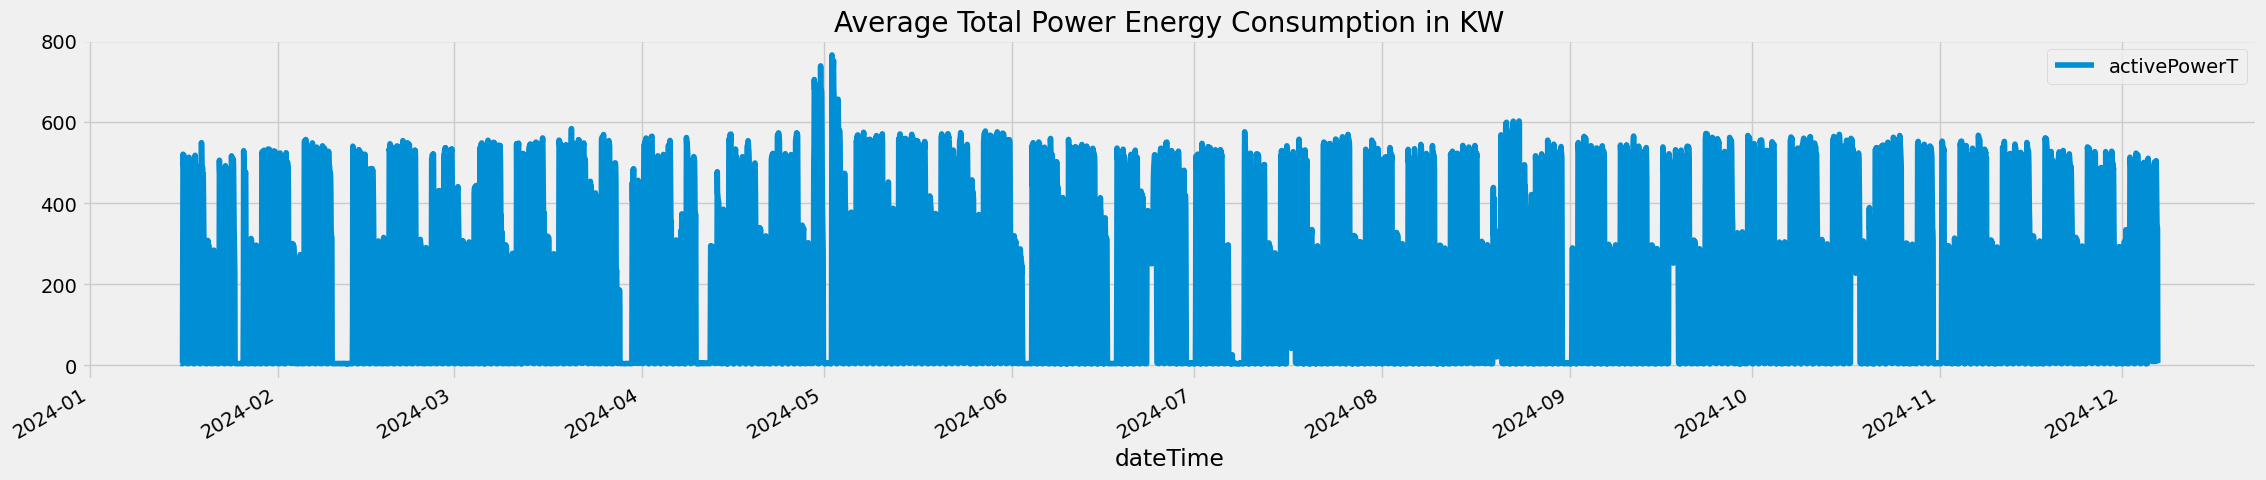

In [ ]:
df.plot( y=['activePowerT'], figsize=(25,5),title ='Average Total Power Energy Consumption in KW')

## Time Series Cross Validation

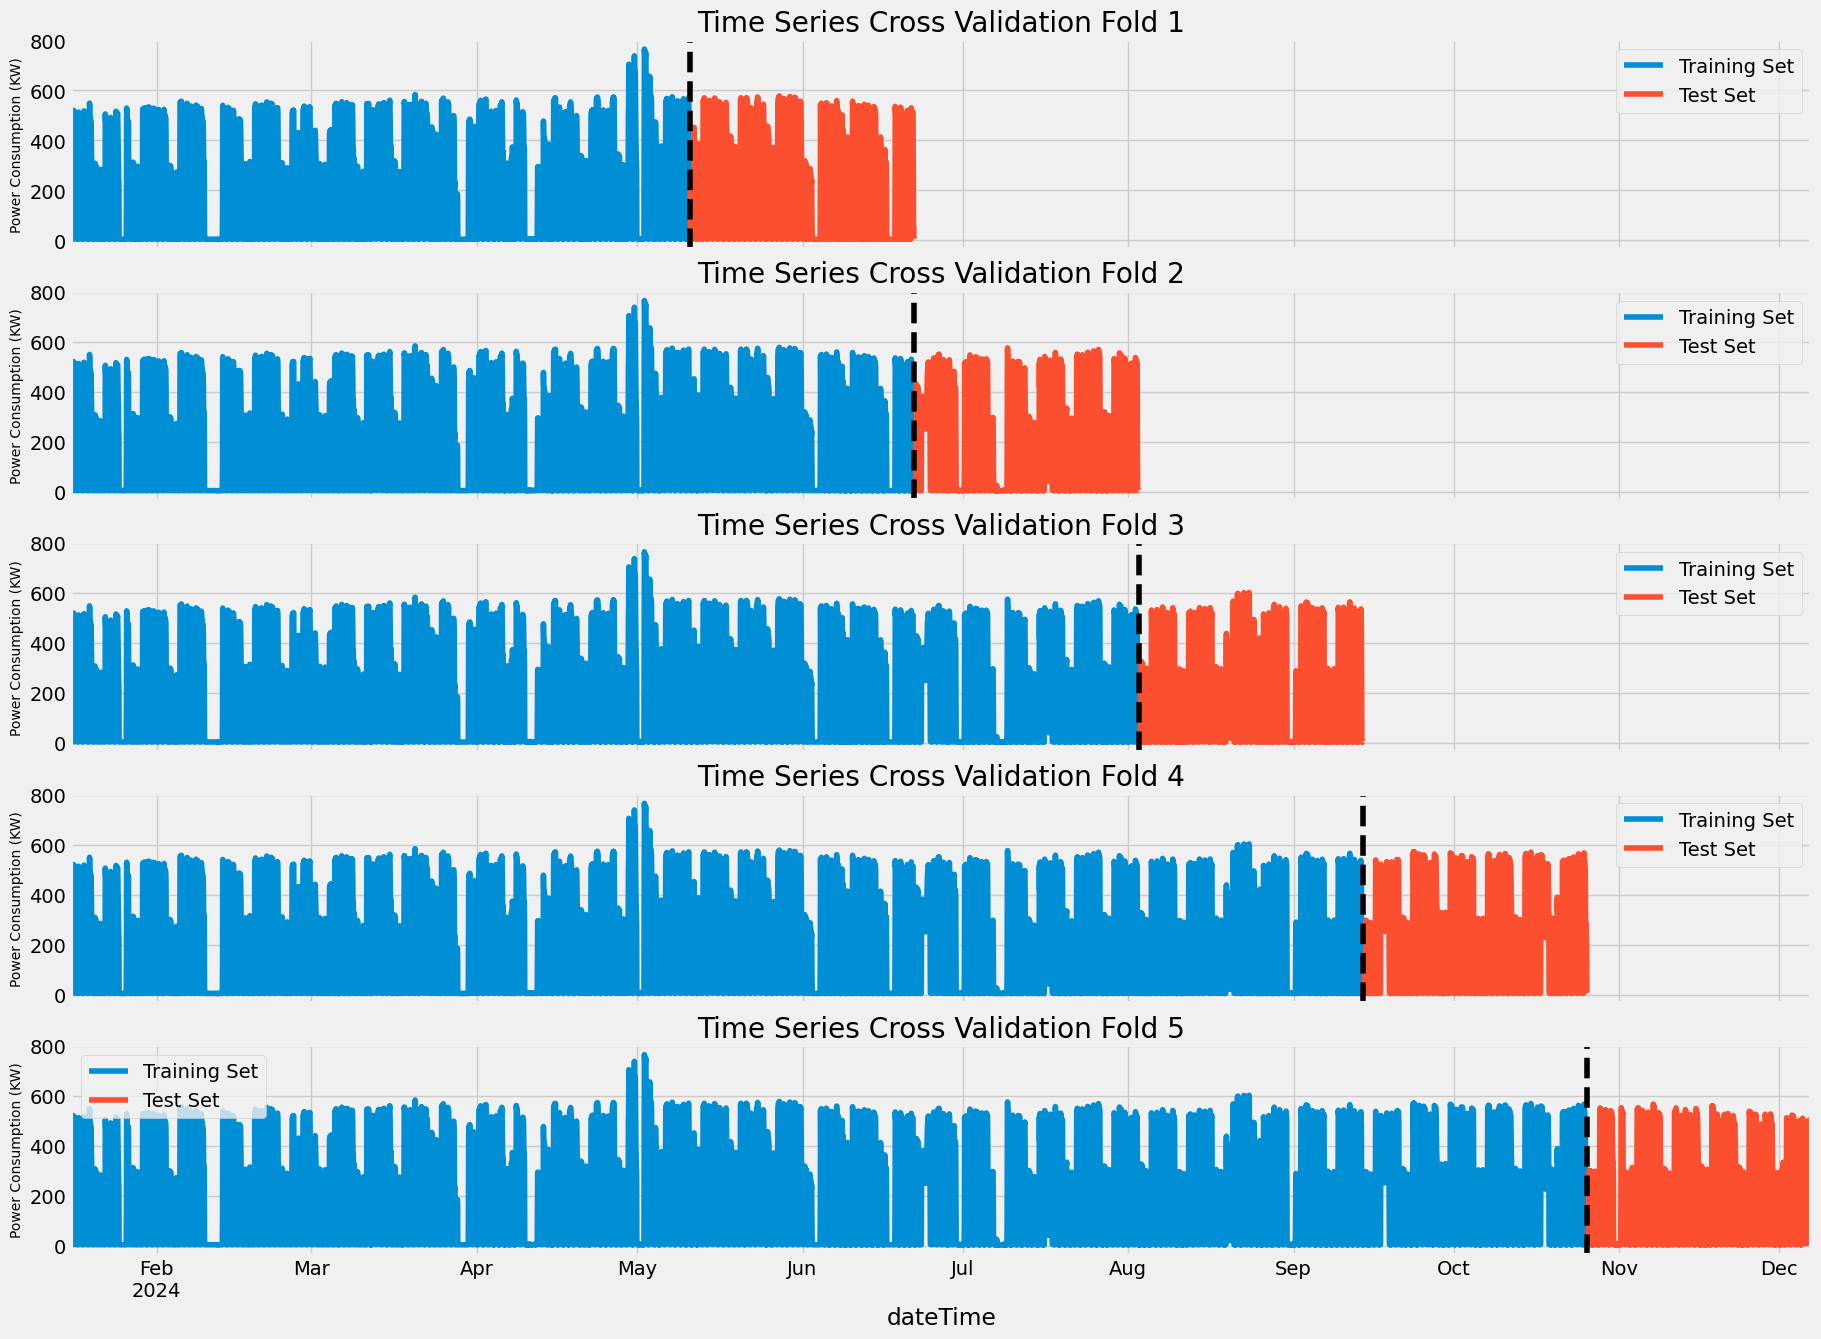

In [ ]:
tss = TimeSeriesSplit(n_splits=5, test_size=14*24*3, gap=0)
df = df.sort_index()
fig, axs = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(20,15))

fold = 0

for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['activePowerT'].plot(ax=axs[fold], label='Training Set',title=f'Time Series Cross Validation Fold {fold+1}')
    test['activePowerT'].plot(ax=axs[fold], label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    axs[fold].legend(['Training Set', 'Test Set'])
    axs[fold].set_ylabel('Power Consumption (KW)',fontsize=10)
    fold+=1
fig.savefig('/content/drive/MyDrive/Images/XGBoost/Time Series')


## Lag Features

In [ ]:
# Create Lag Features
def add_lags(df):
  df = df.copy()
  target_map = df['activePowerT'].to_dict()
  df['lag1'] = (df.index-pd.Timedelta('7 days')).map(target_map)
  df['lag2'] = (df.index-pd.Timedelta('8 days')).map(target_map)
  df['lag3'] = (df.index-pd.Timedelta('9 days')).map(target_map)
  df['lag4'] = (df.index-pd.Timedelta('10 days')).map(target_map)
  target_mapAA = df['activePowerA'].to_dict()
  target_mapCA = df['currentA'].to_dict()

  df['activePowerA_lag1']=(df.index-pd.Timedelta('7 days')).map(target_mapAA)
  df['currentA_lag1']=(df.index-pd.Timedelta('7 days')).map(target_mapCA)
  df['activePowerA_lag2']=(df.index-pd.Timedelta('14 days')).map(target_mapAA)
  df['currentA_lag2']=(df.index-pd.Timedelta('14 days')).map(target_mapCA)
  return df

df = add_lags(df)

In [ ]:
def create_features(df, label=None):
    """
    Creates time series features from datetime index
    """
    df=df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    df['year'] = df.index.year
    return df

df = create_features(df)

# Function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Function to calculate MASE
def mean_absolute_scaled_error(y_true, y_pred):
    n = len(y_true)
    d = np.abs(np.diff(y_true)).sum()/(n-1)
    errors = np.abs(y_true - y_pred)
    return errors.mean()/d

## XGBoost Univariate & Multivariate Forecasting

In [ ]:
fold = 0
preds1= []
score_mse1 = []
score_mae1 = []
score_mape1 = []
score_mase1 = []
score_err1=[]
score_err2=[]
scores1 = []
preds2= []
score_mse2 = []
score_mae2 = []
score_mape2 = []
score_mase2=[]
scores2 = []
val01 = []
val11= []
epochs1=[]
val02 = []
val12= []
epochs2=[]
score_r1 = []
score_r2 = []
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)

    FEATURES1 = ['hour','dayofweek','quarter','month','dayofyear','dayofmonth','weekofyear','activePowerA_lag1','currentA_lag1',"lag1"]
    FEATURES2 = ['hour','dayofweek','quarter','month','dayofyear','dayofmonth','weekofyear']

    TARGET = 'activePowerT'

    X1_train = train[FEATURES1]
    X2_train = train[FEATURES2]
    y_train = train[TARGET]

    X1_test = test[FEATURES1]
    X2_test = test[FEATURES2]
    y_test = test[TARGET]


    reg1= xgb.XGBRegressor(
                          booster='gbtree',
                          n_estimators=3000,
                          early_stopping_rounds=100,
                          learning_rate=0.001,
                          objective='reg:absoluteerror',
                          max_depth=4,
                          gamma=0.8,
                          reg_alpha=0.5,
                          reg_lambda=1.0,
                          min_child_weight=3,
                          subsample = 0.8,
                          colsample_bytree= 0.8
                          )
    reg1.fit(X1_train,y_train,
            eval_set=[(X1_train, y_train), (X1_test, y_test)],
            verbose=1000)


    reg2= xgb.XGBRegressor(
                          booster='gbtree',
                          n_estimators=3000,
                          early_stopping_rounds=100,
                          learning_rate=0.001,
                          objective='reg:absoluteerror',
                          max_depth=4,
                          gamma=0.8,
                          reg_alpha=0.5,
                          reg_lambda=1.0,
                          min_child_weight=3,
                          subsample = 0.8,
                          colsample_bytree= 0.8)
    reg2.fit(X2_train,y_train,
            eval_set=[(X2_train, y_train), (X2_test, y_test)],
            verbose=1000)




    y_pred1 = reg1.predict(X1_test)
    preds1.append(y_pred1)
    score_mse1.append(np.sqrt(mean_squared_error(y_test,y_pred1)))
    score_mae1.append(mean_absolute_error(y_test,y_pred1))
    score_mape1.append( np.mean((np.abs(y_test - y_pred1)) /((np.abs(y_test +np.abs(y_pred1)) / 2))) * 100)
    score_mase1.append(mean_absolute_scaled_error(y_test,y_pred1))
    score_err1.append((abs(statistics.mean(y_test)-statistics.mean(y_pred1))/statistics.mean(y_test) * 100))
    score_r1.append(r2_score(y_test, y_pred1))

    y_pred2 = reg2.predict(X2_test)
    preds2.append(y_pred2)

    score_mse2.append(np.sqrt(mean_squared_error(y_test,y_pred2)))
    score_mae2.append(mean_absolute_error(y_test,y_pred2))
    score_mape2.append( np.mean((np.abs(y_test - y_pred2)) /((np.abs(y_test +np.abs(y_pred2)) / 2))) * 100)
    score_mase2.append(mean_absolute_scaled_error(y_test,y_pred2))
    score_err2.append((abs(statistics.mean(y_test)-statistics.mean(y_pred2))/statistics.mean(y_test) * 100))
    score_r2.append(r2_score(y_test, y_pred2))


    epochs1.append(len(reg1.evals_result_['validation_0']['mae']))
    val01.append(reg1.evals_result_['validation_0']['mae'])
    val11.append(reg1.evals_result_['validation_1']['mae'])

    epochs2.append(len(reg2.evals_result_['validation_0']['mae']))
    val02.append(reg2.evals_result_['validation_0']['mae'])
    val12.append(reg2.evals_result_['validation_1']['mae'])




[0]	validation_0-mae:203.42273	validation_1-mae:205.40129
[1000]	validation_0-mae:97.25478	validation_1-mae:111.97488
[2000]	validation_0-mae:60.07176	validation_1-mae:80.26322
[2999]	validation_0-mae:46.96640	validation_1-mae:69.93853
[0]	validation_0-mae:203.54352	validation_1-mae:205.53189
[1000]	validation_0-mae:110.61333	validation_1-mae:129.84288
[2000]	validation_0-mae:68.02762	validation_1-mae:93.90713
[2999]	validation_0-mae:51.05365	validation_1-mae:76.88744
[0]	validation_0-mae:203.83702	validation_1-mae:201.40372
[1000]	validation_0-mae:98.12162	validation_1-mae:94.46205
[2000]	validation_0-mae:61.29538	validation_1-mae:55.29160
[2999]	validation_0-mae:47.81887	validation_1-mae:42.31144
[0]	validation_0-mae:203.96173	validation_1-mae:201.51388
[1000]	validation_0-mae:113.02102	validation_1-mae:113.40249
[2000]	validation_0-mae:70.53397	validation_1-mae:71.17158
[2999]	validation_0-mae:53.38130	validation_1-mae:58.05004
[0]	validation_0-mae:202.32181	validation_1-mae:189.998

## Training vs Test Set MAE

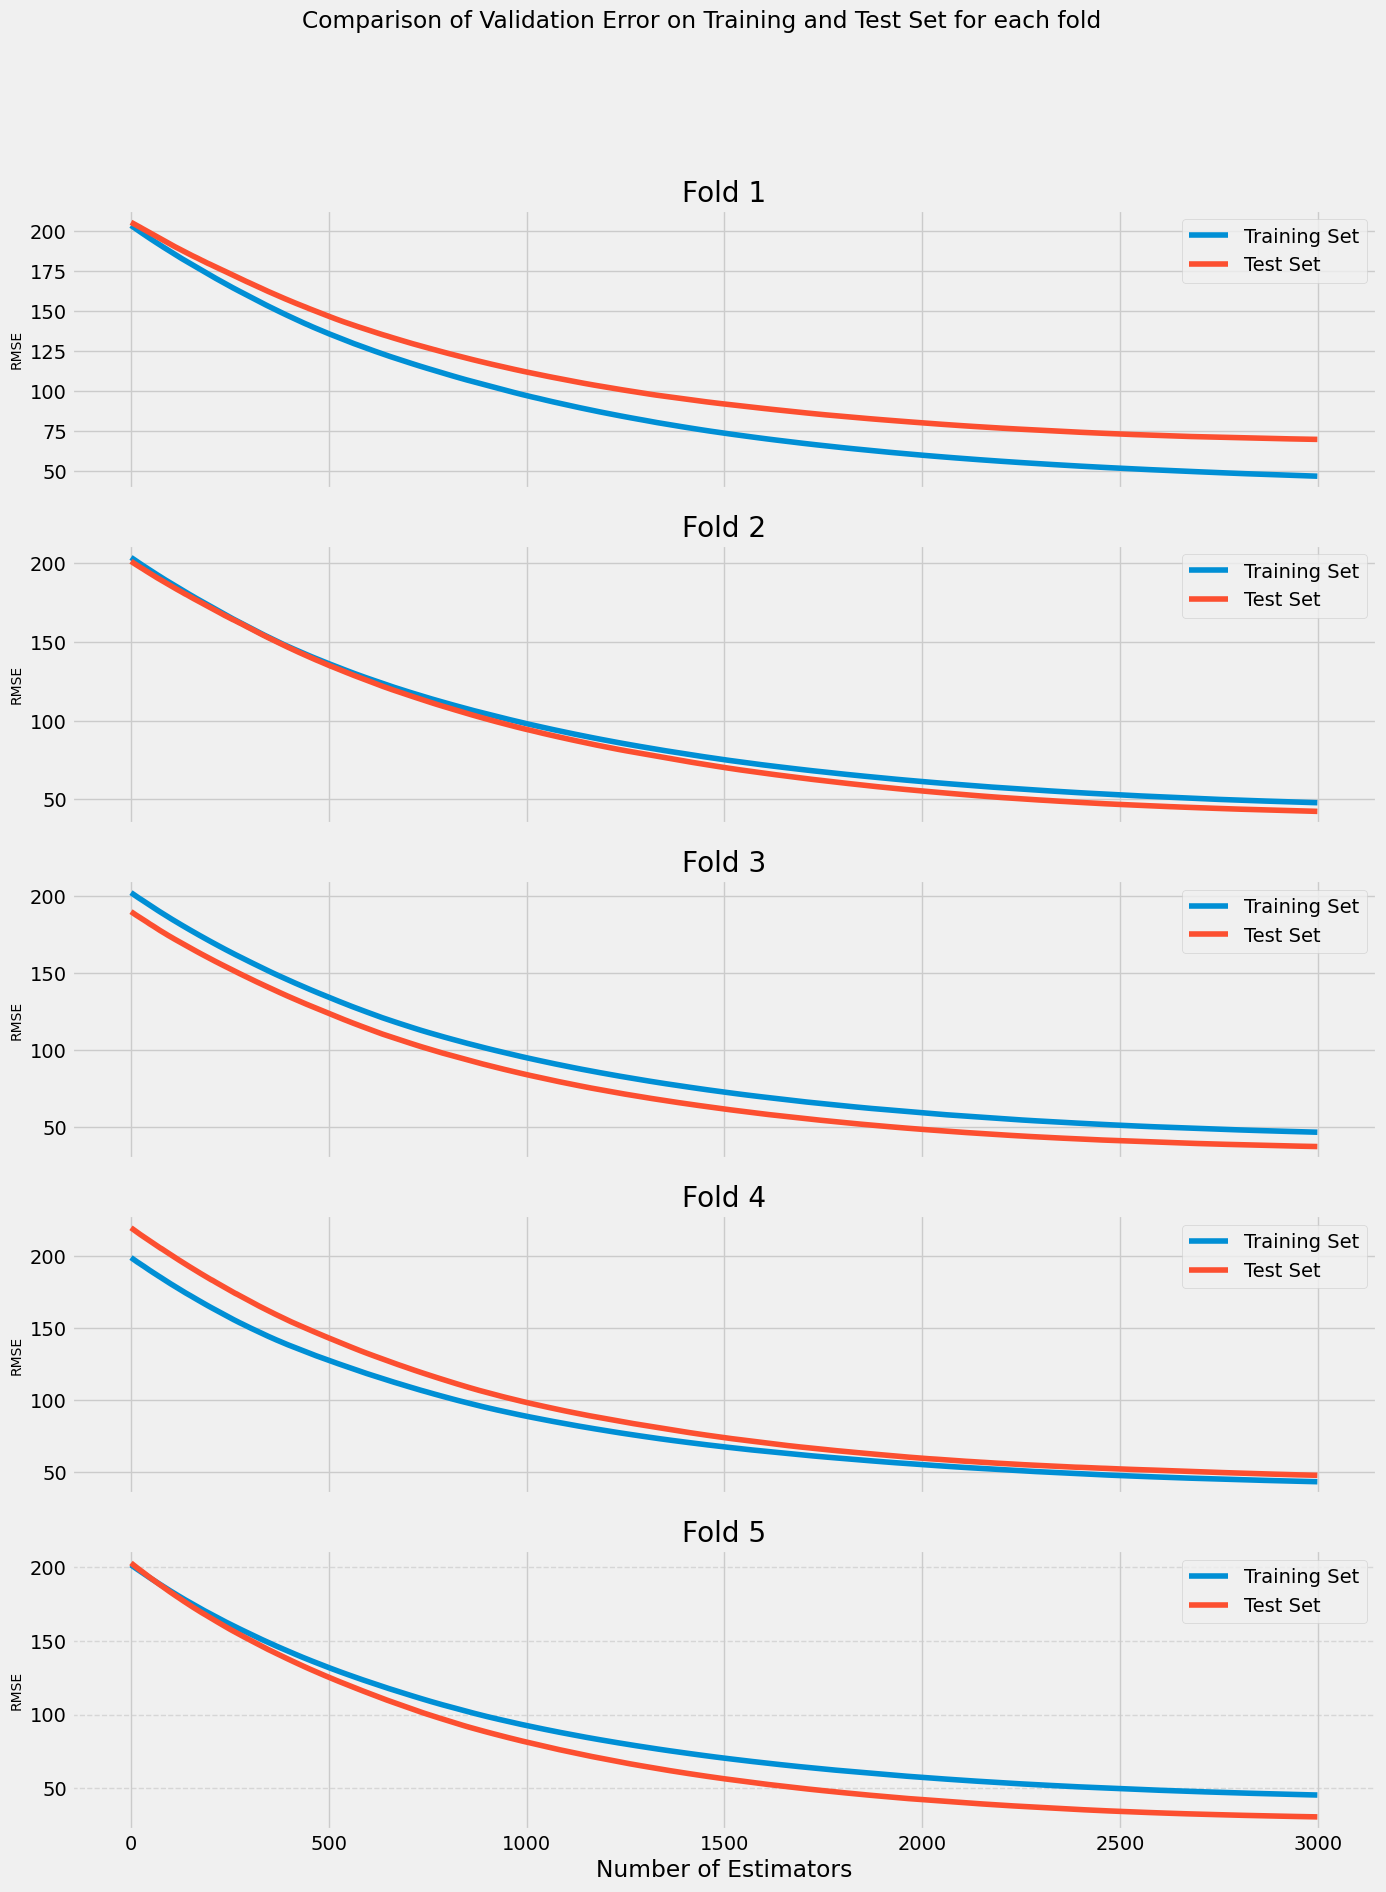

In [ ]:
fig, axs = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(15,20))
for i in range(5):
  x_axis = range(0, epochs1[i])
  axs[i].plot(x_axis, val01[i], label='Train')
  axs[i].plot(x_axis, val11[i], label='Test')
  axs[i].set_title(f'Fold {i+1}')
  axs[i].legend()
  axs[i].legend(['Training Set', 'Test Set'])
  axs[i].set_ylabel('RMSE',fontsize=10)
plt.xlabel('Number of Estimators')
plt.suptitle('Comparison of Validation Error on Training and Test Set for each fold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig.savefig('/content/drive/MyDrive/Images/XGBoost/TrainingTest1')
plt.show()

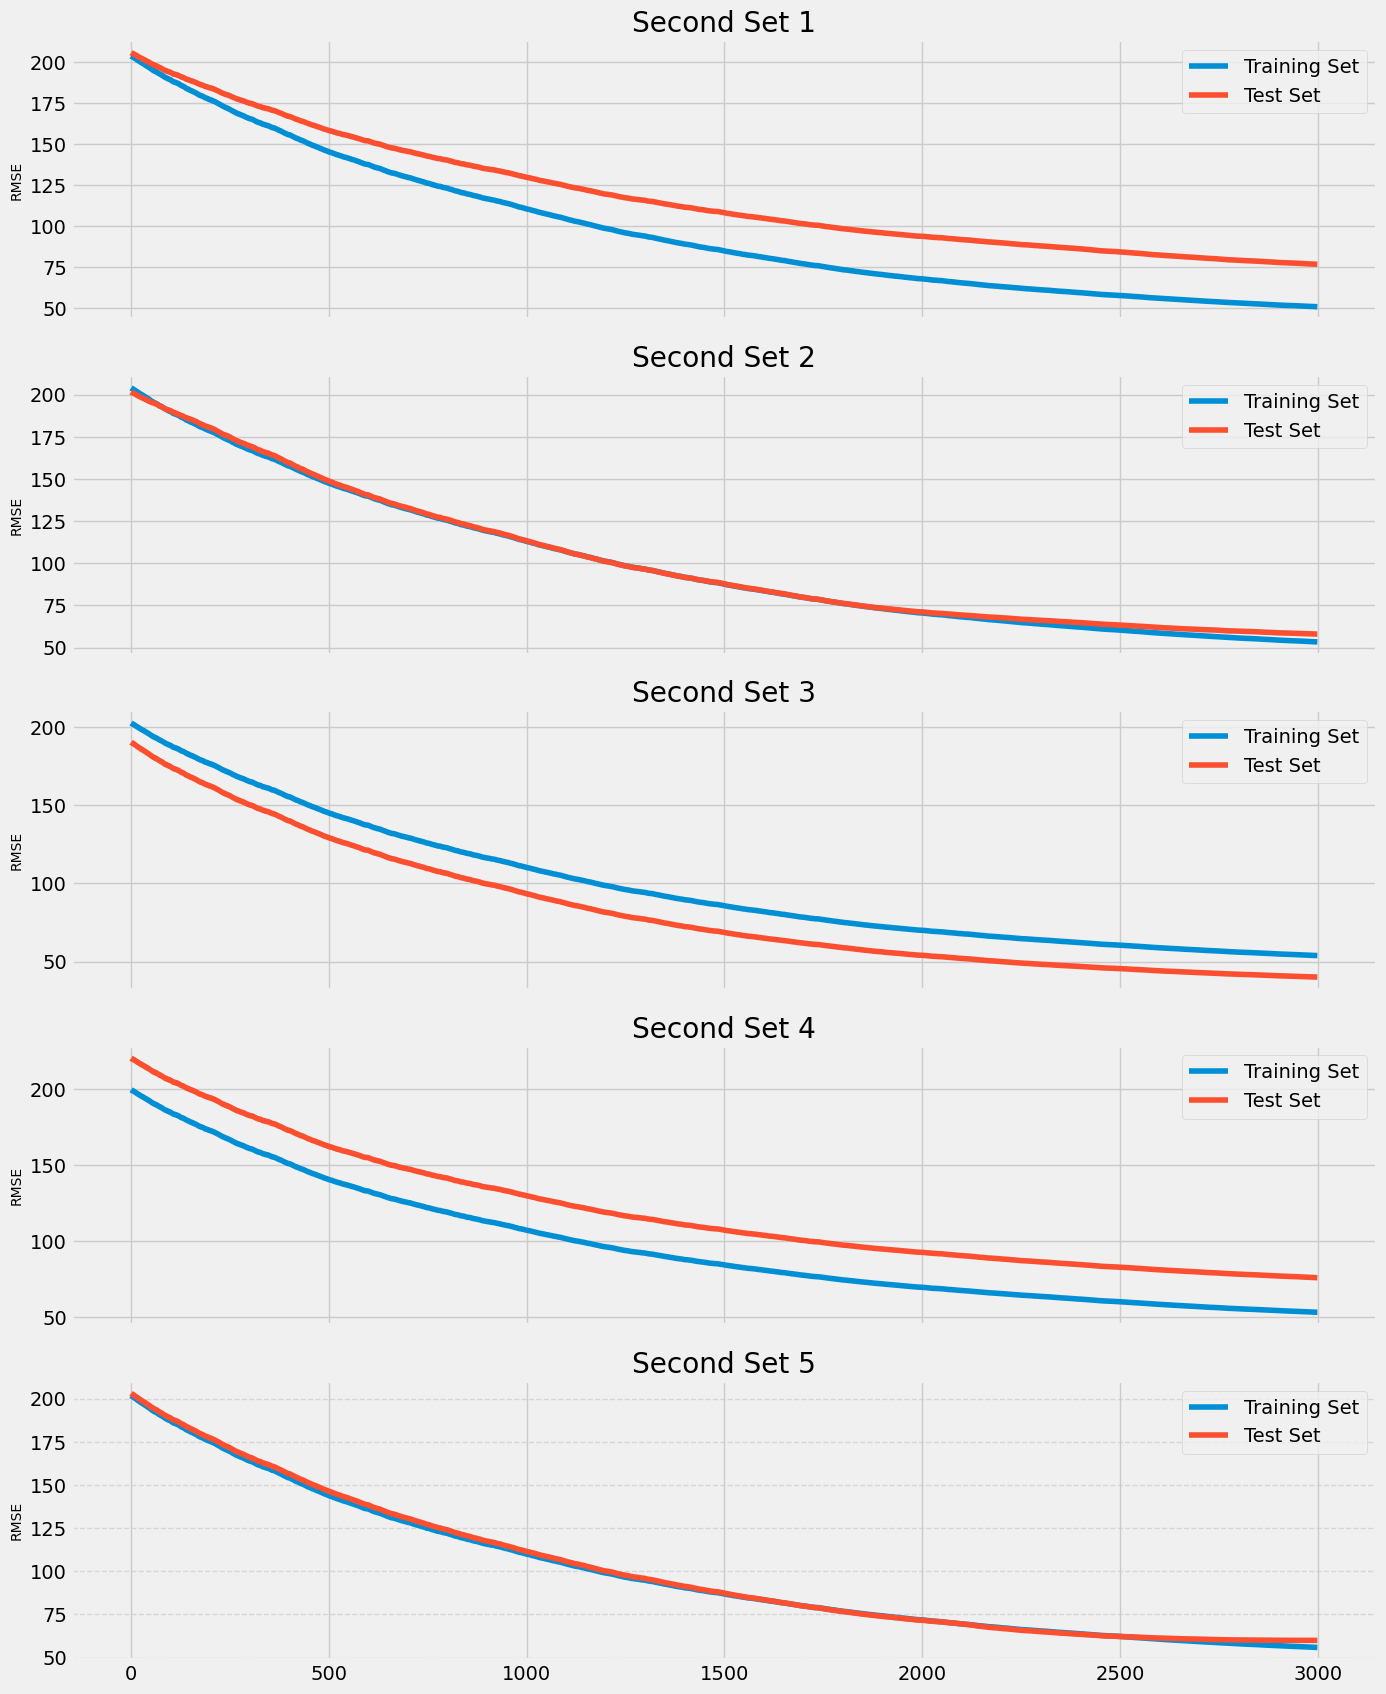

In [ ]:
fig, axs = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(15,20))
for i in range(5):
  x_axis = range(0, epochs2[i])
  axs[i].plot(x_axis, val02[i], label='Train')
  axs[i].plot(x_axis, val12[i], label='Test')
  axs[i].set_title(f'Second Set {i+1}')
  axs[i].legend()
  axs[i].legend(['Training Set', 'Test Set'])
  axs[i].set_ylabel('RMSE',fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig.savefig('/content/drive/MyDrive/Images/XGBoost/TrainingTest2')
plt.show()

## Seasonal Naive Forecast

In [ ]:
snaive_fc =[]
for row_idx,row in test.iterrows():
    hour = row['hour']
    forecast = train['activePowerT'].loc[train['hour']==hour].iloc[-1]
    snaive_fc.append(forecast)

#Forecast on XGBoost Model

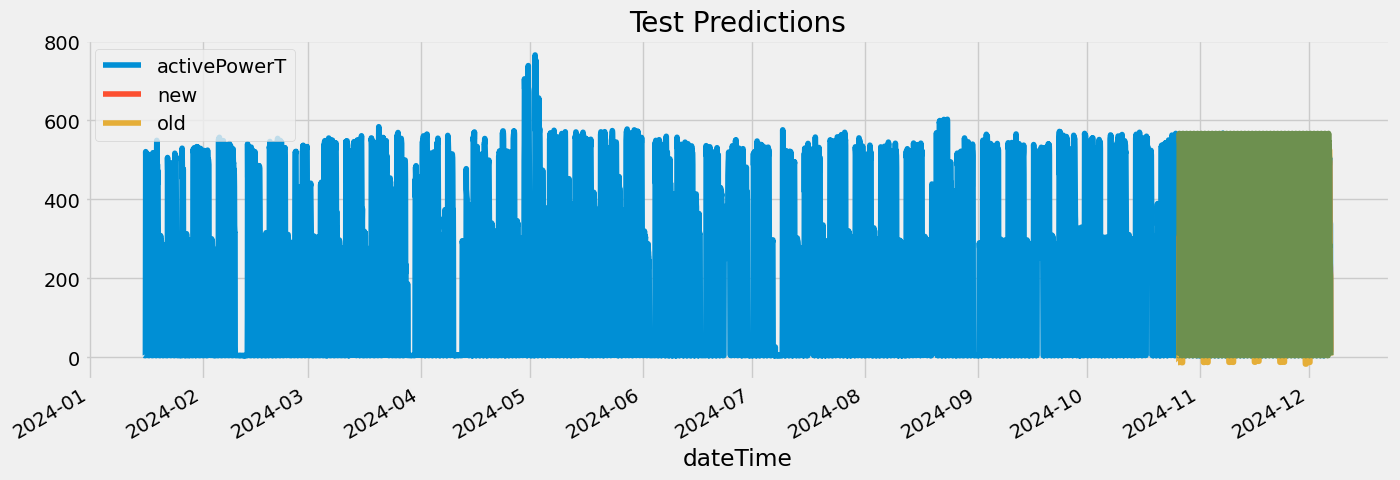

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")

df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
df['activePowerT'] = df['activePowerT'].astype(float)

df = add_lags(df)
df = create_features(df)
test['new'] = reg1.predict(X1_test)
test['old'] = reg2.predict(X2_test)
df= df.merge(test[['old']],how='left',left_index=True,right_index=True)
df= df.merge(test[['new']],how='left',left_index=True,right_index=True)
ax = df[['activePowerT']].plot(figsize=(15,5), title='Test Predictions')
df[['new']].plot(ax=ax)
df[['old']].plot(ax=ax)
snaive_fc = pd.Series(snaive_fc,index=test.index)
snaive_fc.plot(label="Snaive",ax=ax)
plt.show()

## Comparison of Univariate vs Multivariate Forecasting (XGBoost)

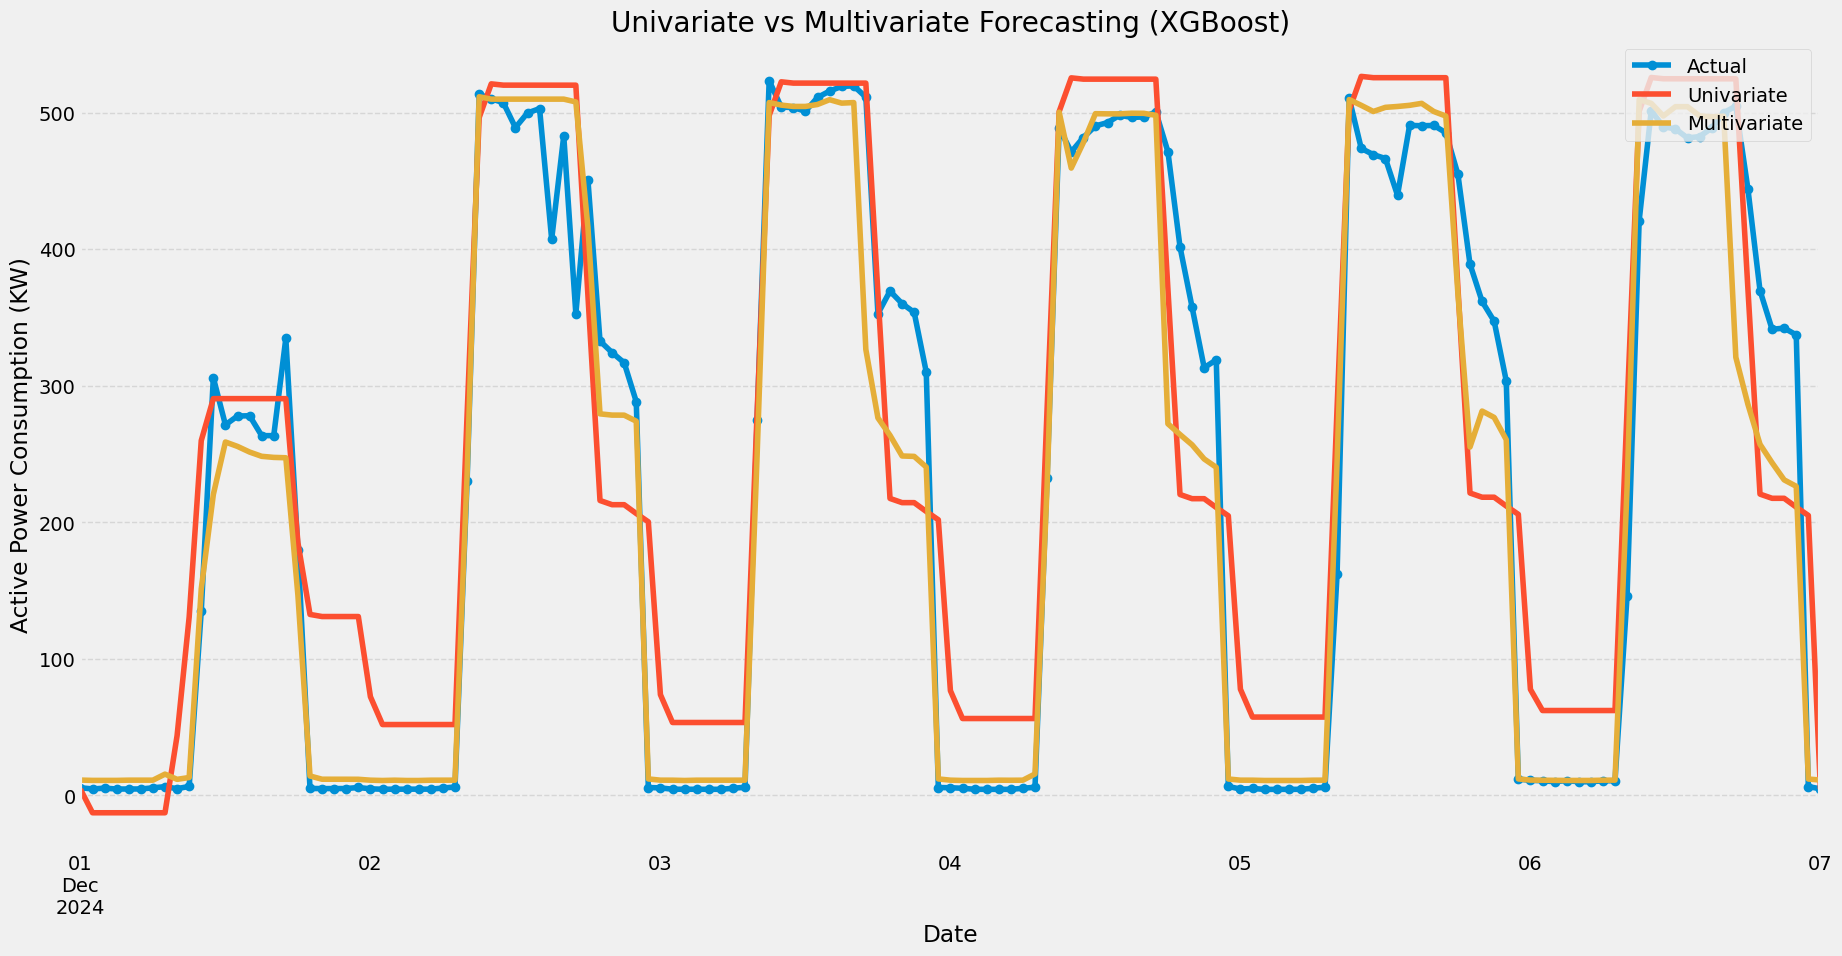

In [ ]:
ax = df.loc[(df.index >= '2024-12-01') & (df.index < '2024-12-08')].plot(y=['activePowerT'],title='Univariate vs Multivariate Forecasting (XGBoost)',xlabel='Date',ylabel='Active Power Consumption (KW)',figsize=(20,10),marker="o")
df.loc[(df.index >= '2024-12-01') & (df.index < '2024-12-08')].plot(y=['old'],ax=ax)
df.loc[(df.index >= '2024-12-01') & (df.index < '2024-12-08')].plot(y=['new'],ax=ax)

ax.legend(['Actual', 'Univariate','Multivariate','Seasonal Naive'],loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Active Power Consumption (KW)')
fig = ax.get_figure()
fig.savefig('/content/drive/MyDrive/Images/XGBoost/Comparison')

plt.show()

## Comparison of Orignal and XGBoost Forecast Model

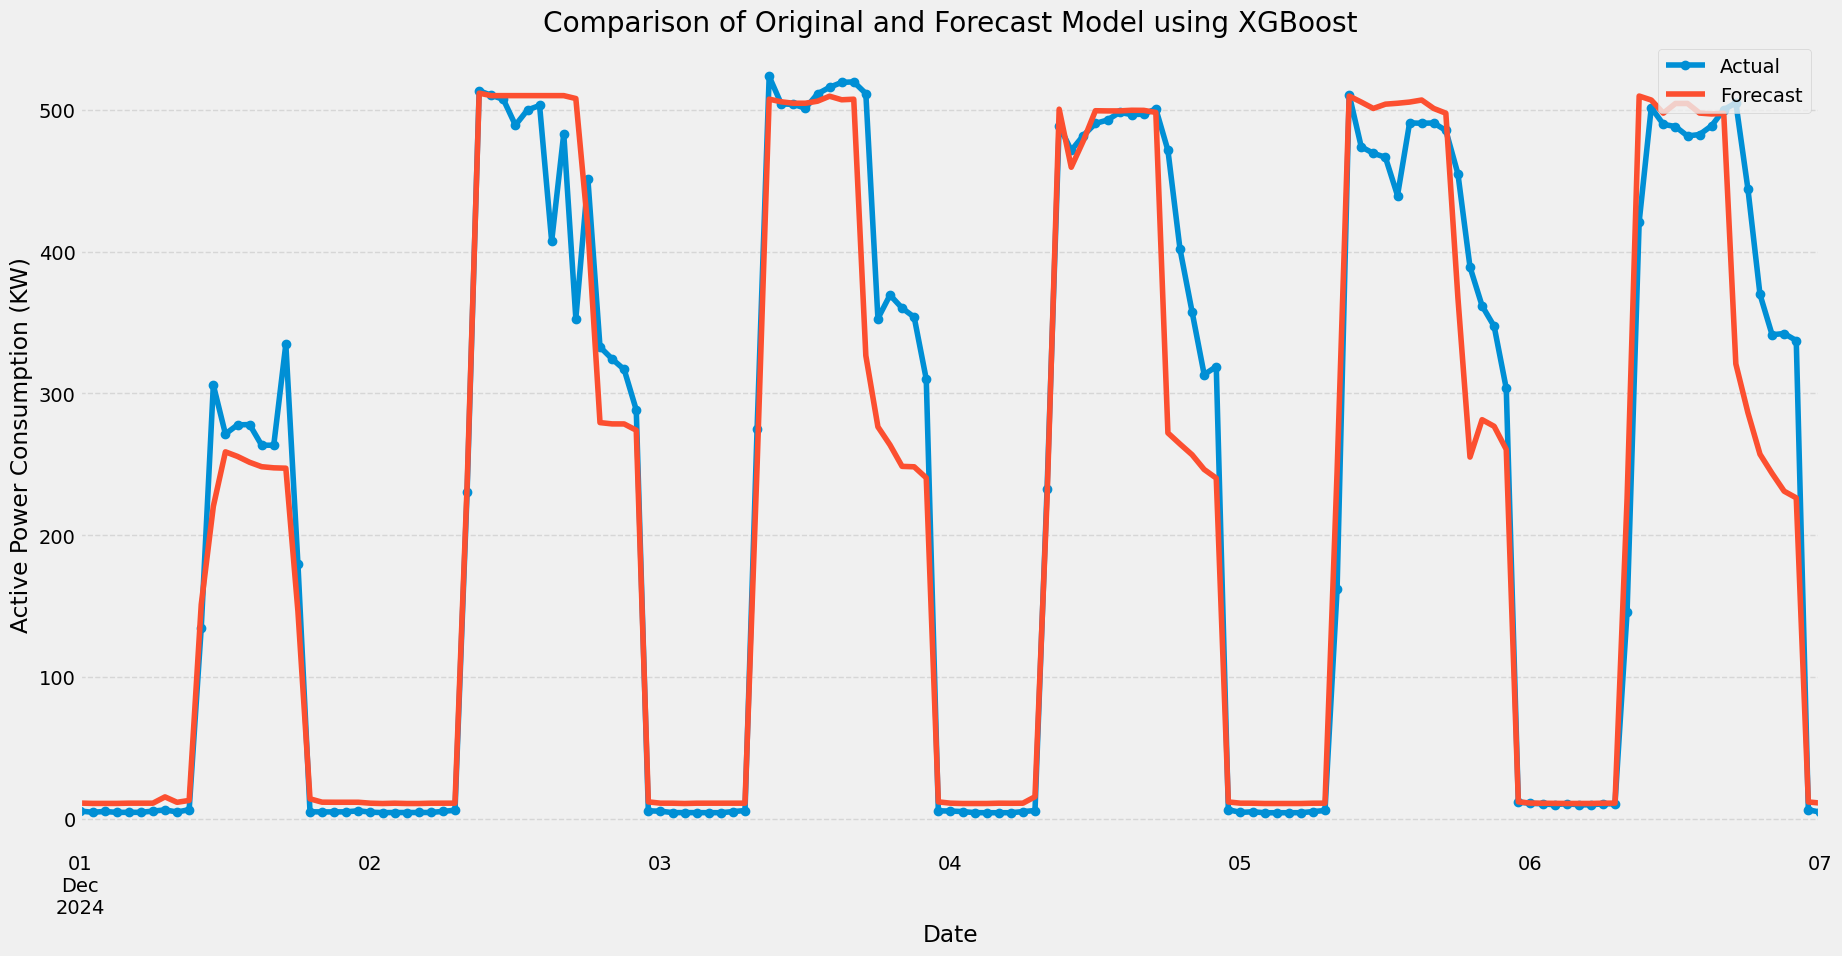

In [ ]:
ax = df.loc[(df.index >= '2024-12-01') & (df.index < '2024-12-08')].plot(y=['activePowerT'],title='Comparison of Original and Forecast Model using XGBoost',xlabel='Date',ylabel='Power Consumption (KW)',figsize=(20,10),marker="o")
df.loc[(df.index >= '2024-12-01') & (df.index < '2024-12-08')].plot(y=['new'],ax=ax)

ax.legend(['Actual','Forecast'],loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Active Power Consumption (KW)')
fig = ax.get_figure()
fig.savefig('/content/drive/MyDrive/Images/XGBoost/Results')

plt.show()

In [ ]:
print(f'Average score (MSE) Advanced: {np.mean(score_mse1):0.2f}')
print(f'Average score (MAE) Advanced: {np.mean(score_mae1):0.2f}')
print(f'Average score (MASE) Advanced: {np.mean(score_mase1):0.2f}')
print(f"Model Error Percentage Advanced:{np.mean(score_err1):0.2f} %")
print(f'Average score (R2) Advanced: {np.mean(score_r1):0.2f}')

print(f'Average score (MSE) Basic: {np.mean(score_mse2):0.2f}')
print(f'Average score (MAE) Basic: {np.mean(score_mae2):0.2f}')
print(f'Average score (MASE) Advanced: {np.mean(score_mase2):0.2f}')
print(f"Model Error Percentage Basic:{np.mean(score_err2):0.2f} %")
print(f'Average score (R2) Basic: {np.mean(score_r2):0.2f}')


print('Average score (MSE) Naive:',np.sqrt(mean_squared_error(test['activePowerT'],snaive_fc)))
print('Average score (MAE) Naive: ',mean_absolute_error(test['activePowerT'],snaive_fc))
print("Model Error Percentage Naive:",np.mean((np.abs(test['activePowerT'] - snaive_fc)) /((np.abs(test['activePowerT']+np.abs(snaive_fc)) / 2))) * 100)
print('Average score (MASE) Naive: ',mean_absolute_scaled_error(test['activePowerT'],snaive_fc))

Average score (MSE) Advanced: 88.92
Average score (MAE) Advanced: 45.65
Average score (MASE) Advanced: 1.08
Model Error Percentage Advanced:6.52 %
Average score (R2) Advanced: 0.83
Average score (MSE) Basic: 99.50
Average score (MAE) Basic: 62.22
Average score (MASE) Advanced: 1.48
Model Error Percentage Basic:12.84 %
Average score (R2) Basic: 0.79
Average score (MSE) Naive: 135.7799558947966
Average score (MAE) Naive:  75.6531056547619
Model Error Percentage Naive: 34.32972333120347
Average score (MASE) Naive:  1.8808417385527871


## Predicting The Future

In [ ]:
X_all = df[FEATURES1]
y_all = df[TARGET]

reg= xgb.XGBRegressor(
                      booster='gbtree',
                          n_estimators=3000,
                          early_stopping_rounds=100,
                          learning_rate=0.001,
                          objective='reg:absoluteerror',
                          max_depth=2,
                          gamma=0.8,
                          reg_alpha=0.5,
                          reg_lambda=1.0,
                          min_child_weight=3,
                          subsample = 0.8,
                          colsample_bytree= 0.8
                          )
reg.fit(X_all,y_all,
      eval_set=[(X_all, y_all)],
      verbose=1000)

[0]	validation_0-mae:201.70306
[1000]	validation_0-mae:98.53026
[2000]	validation_0-mae:66.02682
[2999]	validation_0-mae:55.68298


XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=100,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.8, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.001, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=3000, n_jobs=None,
             num_parallel_tree=None, objective='reg:absoluteerror', ...)

## Out of Sample Forecasting

In [ ]:
# Create Future Dataframe
future = pd.date_range('2024-12-06','2024-12-13',freq ='1h')
future_df = pd.DataFrame(index=future)
future_df['isFuture']= True
df['isFuture']=False
df_and_future = pd.concat([df,future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)
future_w_features = df_and_future.query('isFuture').copy()

future_w_features[FEATURES1].head()

,hour,dayofweek,quarter,month,dayofyear,dayofmonth,weekofyear,activePowerA_lag1,currentA_lag1,lag1
2024-12-06 00:00:00,0,4,4,12,341,6,49,1.4635,6.5090,4.9780
2024-12-06 01:00:00,1,4,4,12,341,6,49,1.4735,6.5280,4.8015
2024-12-06 02:00:00,2,4,4,12,341,6,49,1.4455,6.4750,4.6935
2024-12-06 03:00:00,3,4,4,12,341,6,49,1.4605,6.5000,4.7295
2024-12-06 04:00:00,4,4,4,12,341,6,49,1.4675,6.5095,4.7550


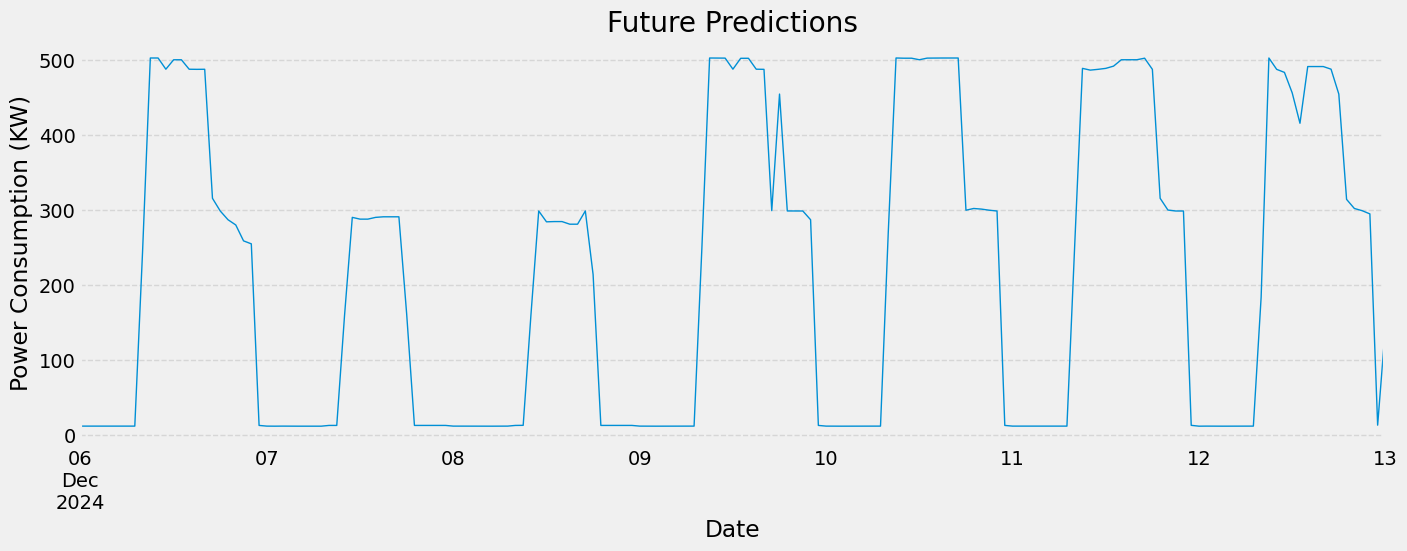

In [ ]:
future_w_features['pred']= reg.predict(future_w_features[FEATURES1])

img = future_w_features['pred'].plot(figsize=(15,5),
                               ms=1,
                               lw=1,
                               title='Future Predictions'
                               )

fig = img.get_figure()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Power Consumption (KW)')
fig.savefig('/content/drive/MyDrive/Images/XGBoost/Future Predictions')

## Model Deployment using Pickle

In [ ]:
import pickle
pickle_out = open("XGBoost.pkl", mode = "wb")
pickle.dump(reg2, pickle_out)
pickle_out.close()

#Evaluation Metrics


## Hyperparameter Tuning

In [ ]:
X_train = train[FEATURES1]
y_train = train[TARGET]

X_test = test[FEATURES1]
y_test = test[TARGET]
def objective(trial):
  # n_estimators = trial.suggest_int('n_estimators', 1000, 5000)
  # max_depth = trial.suggest_int('max_depth', 3, 5)
  # gamma = trial.suggest_float('gamma', 0, 5, step=0.1)
  # reg_alpha = trial.suggest_float('reg_alpha', 0.0, 1.0,step=0.1)
  # reg_lambda = trial.suggest_float('reg_lambda', 0.0, 1.0,step=0.1)
  # min_child_weight = trial.suggest_int('min_child_weight', 1, 3)
  subsample = trial.suggest_float('subsample',0.6, 1.0,step=0.1)
  colsample_bytree = trial.suggest_float('colsample_bytree',0.6, 1.0,step=0.1)


  model = xgb.XGBRegressor(n_estimators=3547,
                          #  learning_rate =0.01,
                           max_depth=3,
                           gamma=0.3,
                           reg_alpha=0.9,
                           reg_lambda=0,
                           min_child_weight=3,
                           subsample = 0.9,
                           colsample_bytree= 0.6,
                           objective='reg:squarederror')
  score = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
  return score.mean()

In [ ]:
study = optuna.create_study(direction='maximize',sampler=optuna.samplers.RandomSampler())
study.optimize(objective, n_trials=100)

[I 2025-04-08 15:05:28,195] A new study created in memory with name: no-name-9dda7fb0-1ca8-44ae-a047-3211b9ab1228
[I 2025-04-08 15:05:34,567] Trial 0 finished with value: -15859.32978195586 and parameters: {'subsample': 0.8, 'colsample_bytree': 0.6}. Best is trial 0 with value: -15859.32978195586.
[I 2025-04-08 15:05:42,231] Trial 1 finished with value: -15859.32978195586 and parameters: {'subsample': 0.7, 'colsample_bytree': 0.8}. Best is trial 0 with value: -15859.32978195586.
[I 2025-04-08 15:05:49,943] Trial 2 finished with value: -15859.32978195586 and parameters: {'subsample': 1.0, 'colsample_bytree': 0.9}. Best is trial 0 with value: -15859.32978195586.
[I 2025-04-08 15:05:56,326] Trial 3 finished with value: -15859.32978195586 and parameters: {'subsample': 0.6, 'colsample_bytree': 0.7}. Best is trial 0 with value: -15859.32978195586.
[I 2025-04-08 15:06:04,251] Trial 4 finished with value: -15859.32978195586 and parameters: {'subsample': 0.9, 'colsample_bytree': 0.8}. Best is t

KeyboardInterrupt: 

In [ ]:


bestmodel = xgb.XGBRegressor(n_estimators=10000,
                          learning_rate =0.001,
                          max_depth=5,
                          gamma=0.8,
                          reg_alpha=0.5,
                          reg_lambda=1.0,
                          min_child_weight=3,
                          subsample = 0.8,
                          colsample_bytree= 0.8,
                          objective='reg:absoluteerror')

score = cross_val_score(bestmodel, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
reg.fit(X_train,y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=1000)
y_pred = reg.predict(X_test)

In [ ]:
print(np.sqrt(mean_squared_error(y_test, y_pred)))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))